In [1]:
import pygmt
import numpy as np
import xarray as xr

In [2]:
paths = {'NEMO': '/results2/SalishSea/nowcast-green.202111/',
         'coords': '/ocean/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
         'coordsWW3': '/ocean/jvalenti/MOAD/grid2/WW3_grid.nc',
         'mask': '/ocean/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc',
         'bat': '/ocean/jvalenti/MOAD/grid/bathymetry_202108.nc',
         'out': '/home/jvalenti/MOAD/results',
         'home': '/home/jvalenti/MOAD/analysis-jose/notebooks/parcels'}

In [3]:
coords = xr.open_dataset(paths['coords'], decode_times=False)
mask = xr.open_dataset(paths['mask'])

In [4]:
# ------------------------------------------------------------------
# 1. Regridding: NEMO's nav_lon/nav_lat are curvilinear, not a regular
#    lon/lat grid, so GMT's grdimage/grdcontour need this done once.
# ------------------------------------------------------------------
def curvilinear_to_grid(lon2d, lat2d, z2d, spacing, region):
    lon, lat, z = lon2d.values.ravel(), lat2d.values.ravel(), z2d.values.ravel()
    good = np.isfinite(z)
    return pygmt.nearneighbor(
        x=lon[good], y=lat[good], z=z[good],
        spacing=spacing, region=region, search_radius=f"{spacing*2}d",
    )

region = [
    float(coords.nav_lon.min()), float(coords.nav_lon.max()),
    float(coords.nav_lat.min()), float(coords.nav_lat.max()),
]
spacing = 0.005  # tune to your native model resolution

bathy_grid = curvilinear_to_grid(coords.nav_lon, coords.nav_lat, mask.totaldepth, spacing, region)
umask_grid = curvilinear_to_grid(coords.nav_lon, coords.nav_lat, mask.tmask[0, 0], spacing, region)

# ------------------------------------------------------------------
# 2. Domain footprint polygon (walk the four edges of the curvilinear
#    grid) — used both to restrict the land-mask overlay and for the
#    minimap inset outline.
# ------------------------------------------------------------------

lon_b = np.r_[coords.nav_lon[0, :], coords.nav_lon[:, -1],
              coords.nav_lon[-1, ::-1], coords.nav_lon[::-1, 0]]
lat_b = np.r_[coords.nav_lat[0, :], coords.nav_lat[:, -1],
              coords.nav_lat[-1, ::-1], coords.nav_lat[::-1, 0]]

# ------------------------------------------------------------------
# 3. Combined topo-bathy: real SRTM relief for land, model bathymetry
#    for water, merged into one signed elevation grid.
# ------------------------------------------------------------------
# relief = pygmt.datasets.load_earth_relief(resolution="03s", region=region)
# relief_rs = pygmt.grdsample(grid=relief, region=region, spacing=spacing)
 
# bathy_da = xr.open_dataarray("bathy_regridded.nc")
# relief_arr = relief_rs.reindex_like(bathy_da, method="nearest").values
 
# is_water = np.isfinite(bathy_da.values)
# combined = bathy_da.copy(data=np.where(is_water, -bathy_da.values, relief_arr))
# combined.to_netcdf("combined_topo_bathy.nc")

nearneighbor [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
nearneighbor [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
nearneighbor (gmtapi_init_grdheader): Please select compatible -R and -I values
nearneighbor [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
nearneighbor [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
nearneighbor (gmtapi_init_grdheader): Please select compatible -R and -I values


In [5]:
# ------------------------------------------------------------------
# 4. Model land polygons (with holes for water) + coastline, traced
#    directly from the native curvilinear grid using tmask (NOT umask
#    -- umask is staggered onto velocity points and introduces a
#    half-cell coastline offset relative to the tmask-based land fill
#    below, so both the fill AND the outline need to come from tmask
#    for them to line up exactly).
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
from shapely.strtree import STRtree
import geopandas as gpd
 
cs_line = plt.contour(coords.nav_lon, coords.nav_lat, mask.tmask[0, 0], levels=[0.5])
plt.close('all')
coast_lines = cs_line.allsegs[0]
 
def ring_signed_area(ring):
    x, y = ring[:, 0], ring[:, 1]
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])
 
cs_fill = plt.contourf(coords.nav_lon, coords.nav_lat, mask.tmask[0, 0], levels=[-0.5, 0.5])
plt.close('all')
 
exteriors, holes = [], []
for path in cs_fill.get_paths():
    for ring in path.to_polygons():
        if len(ring) < 4:
            continue
        (exteriors if ring_signed_area(ring) > 0 else holes).append(ring)
 
ext_polys = [Polygon(r) for r in exteriors]
tree = STRtree(ext_polys)
 
holes_by_ext = {i: [] for i in range(len(ext_polys))}
for h in holes:
    pt = Polygon(h).representative_point()
    for idx in np.atleast_1d(tree.query(pt)):
        idx = int(idx)
        if ext_polys[idx].contains(pt):
            holes_by_ext[idx].append(h)
            break
 
land_shape = MultiPolygon([Polygon(exteriors[i], holes_by_ext[i]) for i in range(len(ext_polys))])
gdf = gpd.GeoDataFrame(geometry=[land_shape], crs="EPSG:4326")
 

In [6]:
# ------------------------------------------------------------------
# 5. Main map
# ------------------------------------------------------------------
proj = "M25c"
fig = pygmt.Figure()
pygmt.config(FONT_ANNOT_PRIMARY="14p,Helvetica")
 
fig.basemap(region=region, projection=proj, frame=["WSne", "xa1", "ya1"])
 
# --- Custom CPT: oleron gradient for water, flat color for land ---
land_color = "#F4C280"
 
# CPT that actually colors the raster — water shaded by depth,
# land pinned to a single flat color from 0 up to a safe ceiling
pygmt.makecpt(cmap="oleron", series=[-500, 0, 10], continuous=True,
              background=True, output="water_for_raster.cpt")
 
with open("water_for_raster.cpt") as f:
    lines = f.readlines()
 
body = [l for l in lines if not l.startswith(("B", "F", "N"))]
special = [l for l in lines if l.startswith(("B", "F", "N"))]
body_with_land = body + [f"0\t{land_color}\t3000\t{land_color}\n"]
 
with open("combined.cpt", "w") as f:
    f.writelines(body_with_land + special)
 
# CPT purely for colorbar display — sign flipped so depth reads as positive
pygmt.makecpt(cmap="oleron", reverse="z", series=[0, 500, 10], continuous=True,
              background=True, output="water_only.cpt")
 
fig.grdimage(grid="combined_topo_bathy.nc", cmap="combined.cpt", nan_transparent=True)
fig.colorbar(frame=["af", "x+lDepth (m)"], position="JBC+w15c/0.4c+h+o0/1c+e",
             cmap="water_only.cpt")
 
# Model's own land, solid fill (with water holes), drawn ON TOP of the raster
fig.plot(data=gdf, fill="#d3d3d3", pen="0.4p,black")
 
# Smooth model coastline, on top of the land fill
for seg in coast_lines:
    fig.plot(x=seg[:, 0], y=seg[:, 1], pen="0.5p,black")
 

ERROR 1: PROJ: proj_create_from_database: Open of /ocean/jvalenti/MOAD/analysis-jose/.pixi/envs/default/share/proj failed


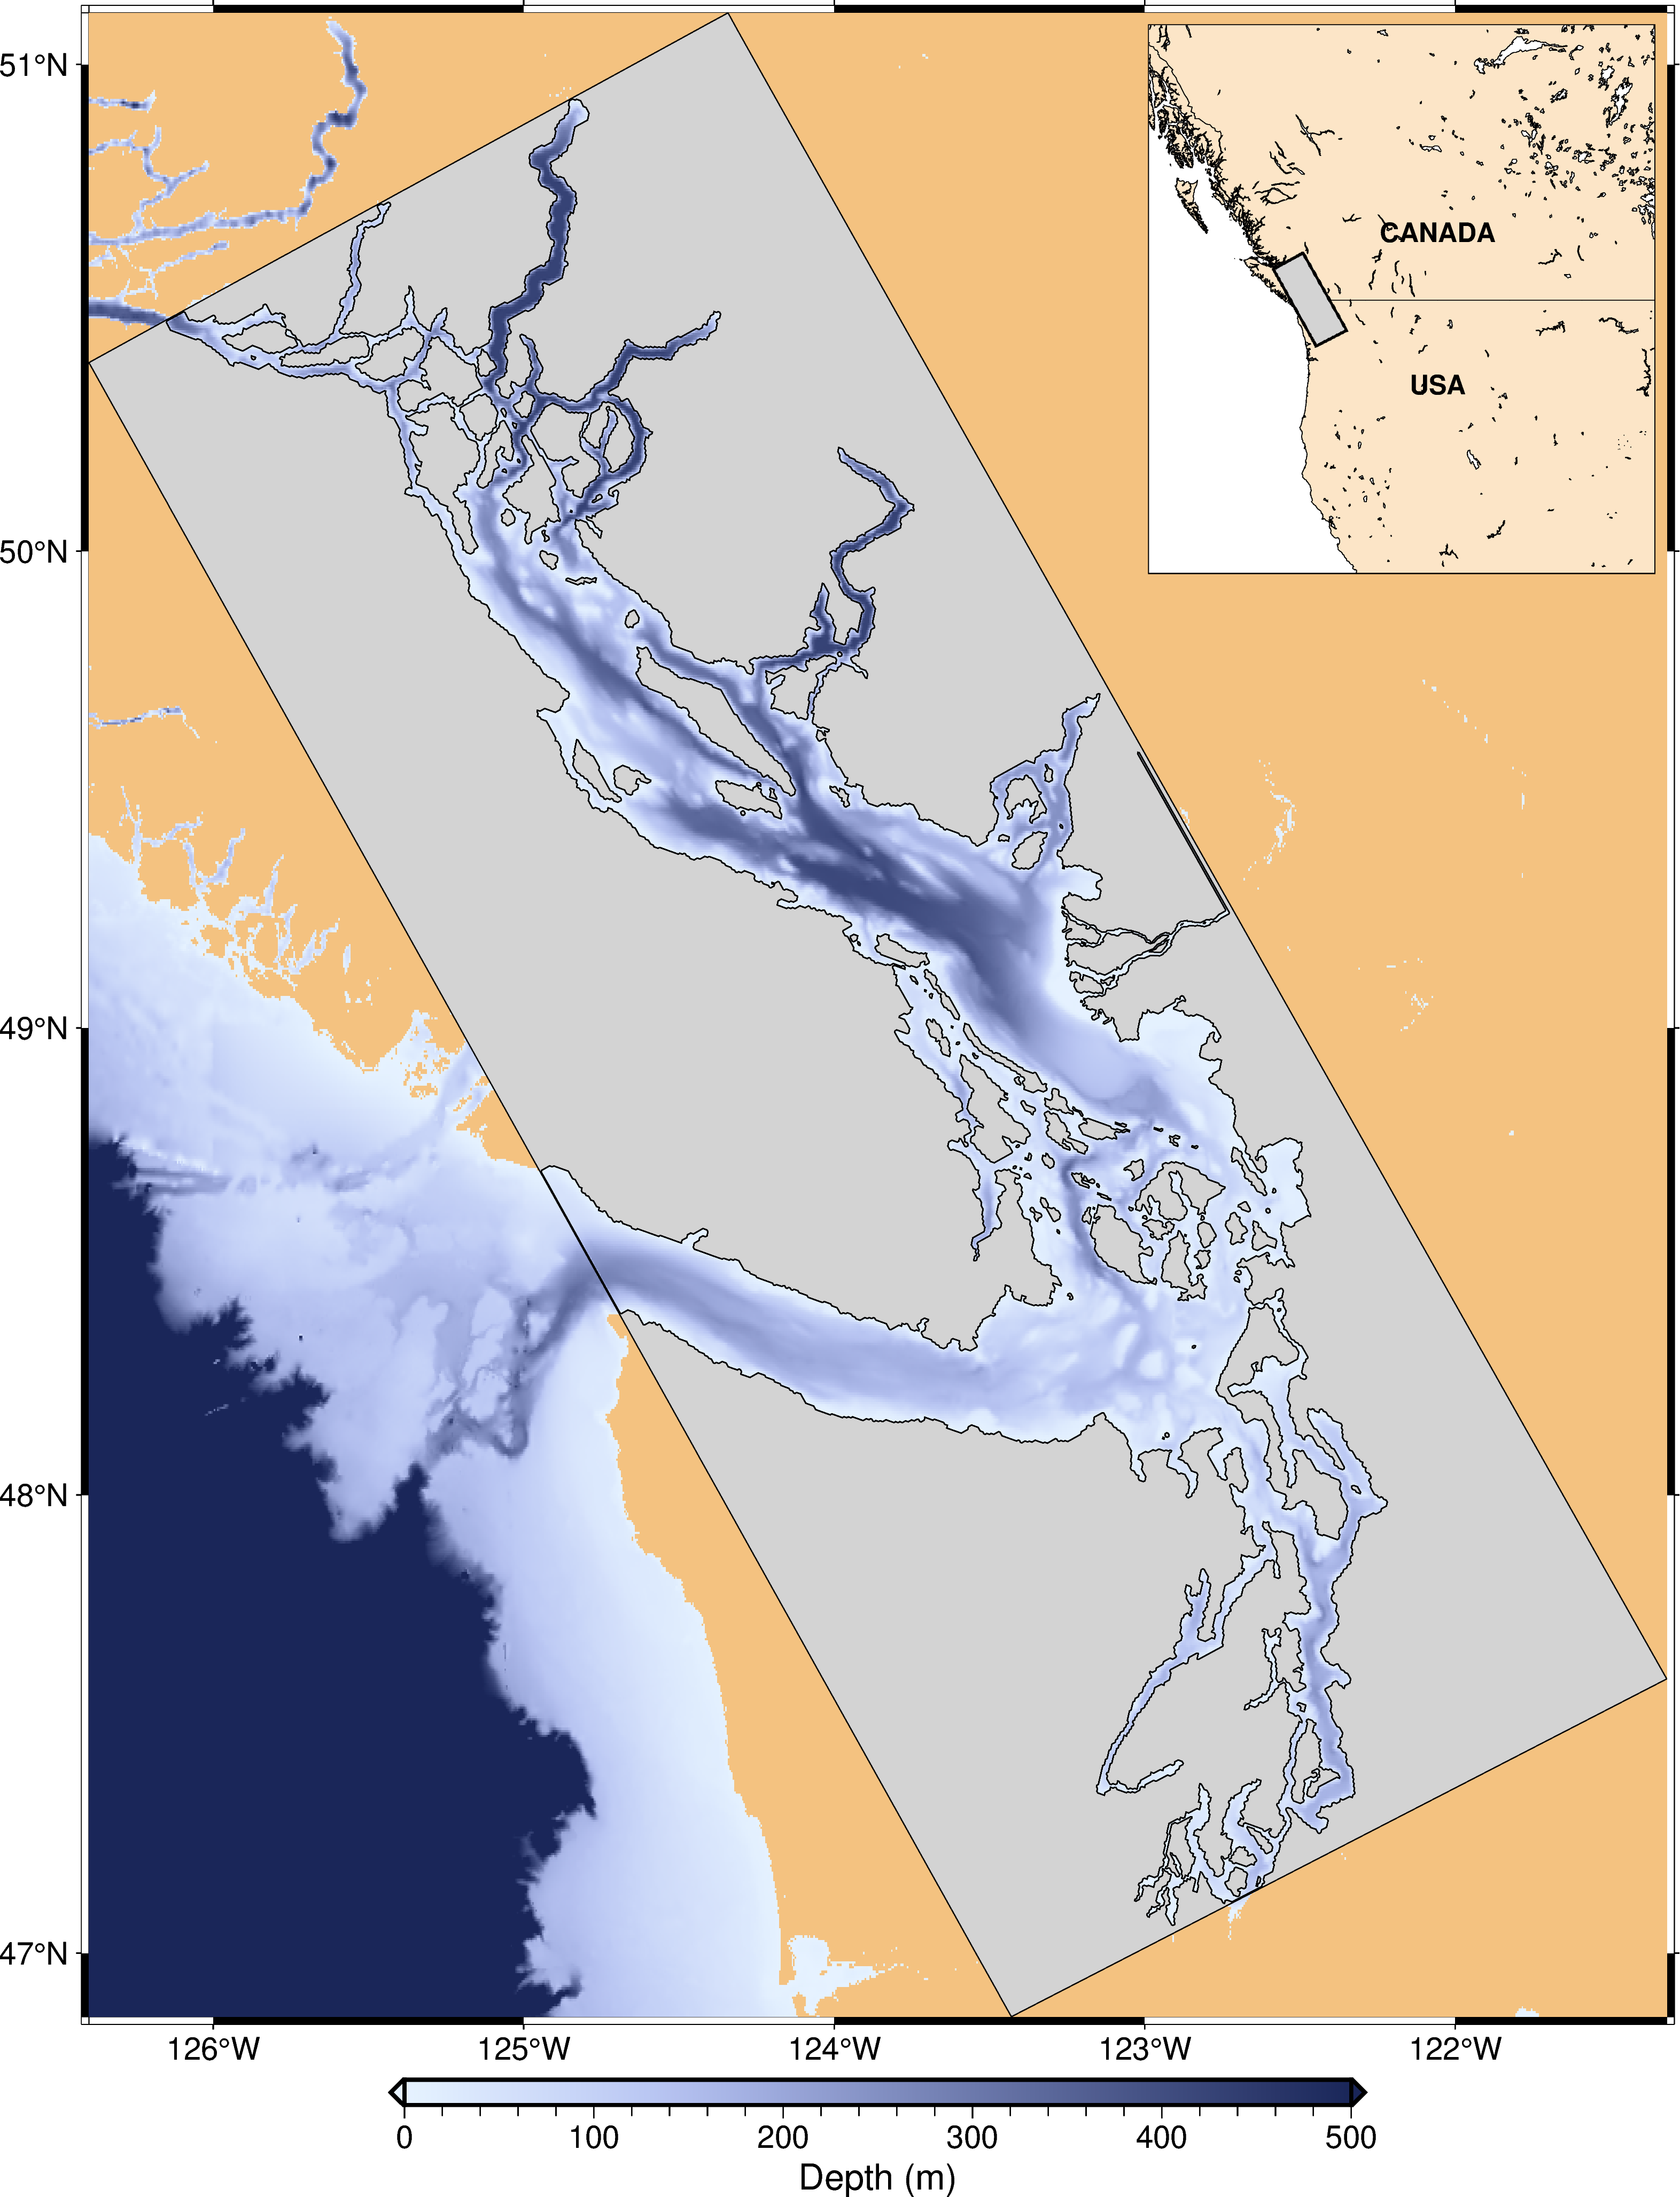

In [ ]:
# ------------------------------------------------------------------
# 6. Minimap inset, top-right
# ------------------------------------------------------------------
inset_region = [-135, -100, 35, 60]
inset_proj = "M8c"
 
with fig.inset(position="jTR+o0.2c", region=inset_region, projection=inset_proj,
                box="+gwhite+p1p"):
    fig.coast(
        land="#FCE5C7", water="white",
        shorelines="0.3p,black", borders="1/0.3p,black",
    )
    fig.text(x=-115, y=52, text="CANADA", font="12p,Helvetica-Bold,black", justify="CM")
    fig.text(x=-115, y=45, text="USA", font="12p,Helvetica-Bold,black", justify="CM")
    fig.plot(x=lon_b, y=lat_b, pen="1p,black", close=True, fill="#d3d3d3")
 

In [8]:
def add_text_with_outline(fig, x, y, text, angle,size=24,stroke = 0.02,arrowx = False,arrowy = False, arrowoff = 0.05):
    font_black = rf"{size}p,Helvetica-Bold,black"
    font_white = rf"{size}p,Helvetica-Bold,white"
    directions = [(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1) if (dx, dy) != (0, 0)]
    for dx, dy in directions:
        fig.text(x=x, y=y, text=text, font=font_black, justify="CM",
                      angle=angle, offset=f"{dx*stroke}c/{dy*stroke}c")
    fig.text(x=x, y=y, text=text, font=font_white, justify="CM", angle=angle)
    if arrowx and arrowy:
        fig.plot(
        x=[x], y=[y+arrowoff],
        style="v0.6c+e+s",
        pen="2.5p,black",
        fill="black",
        direction=([arrowx], [arrowy]))

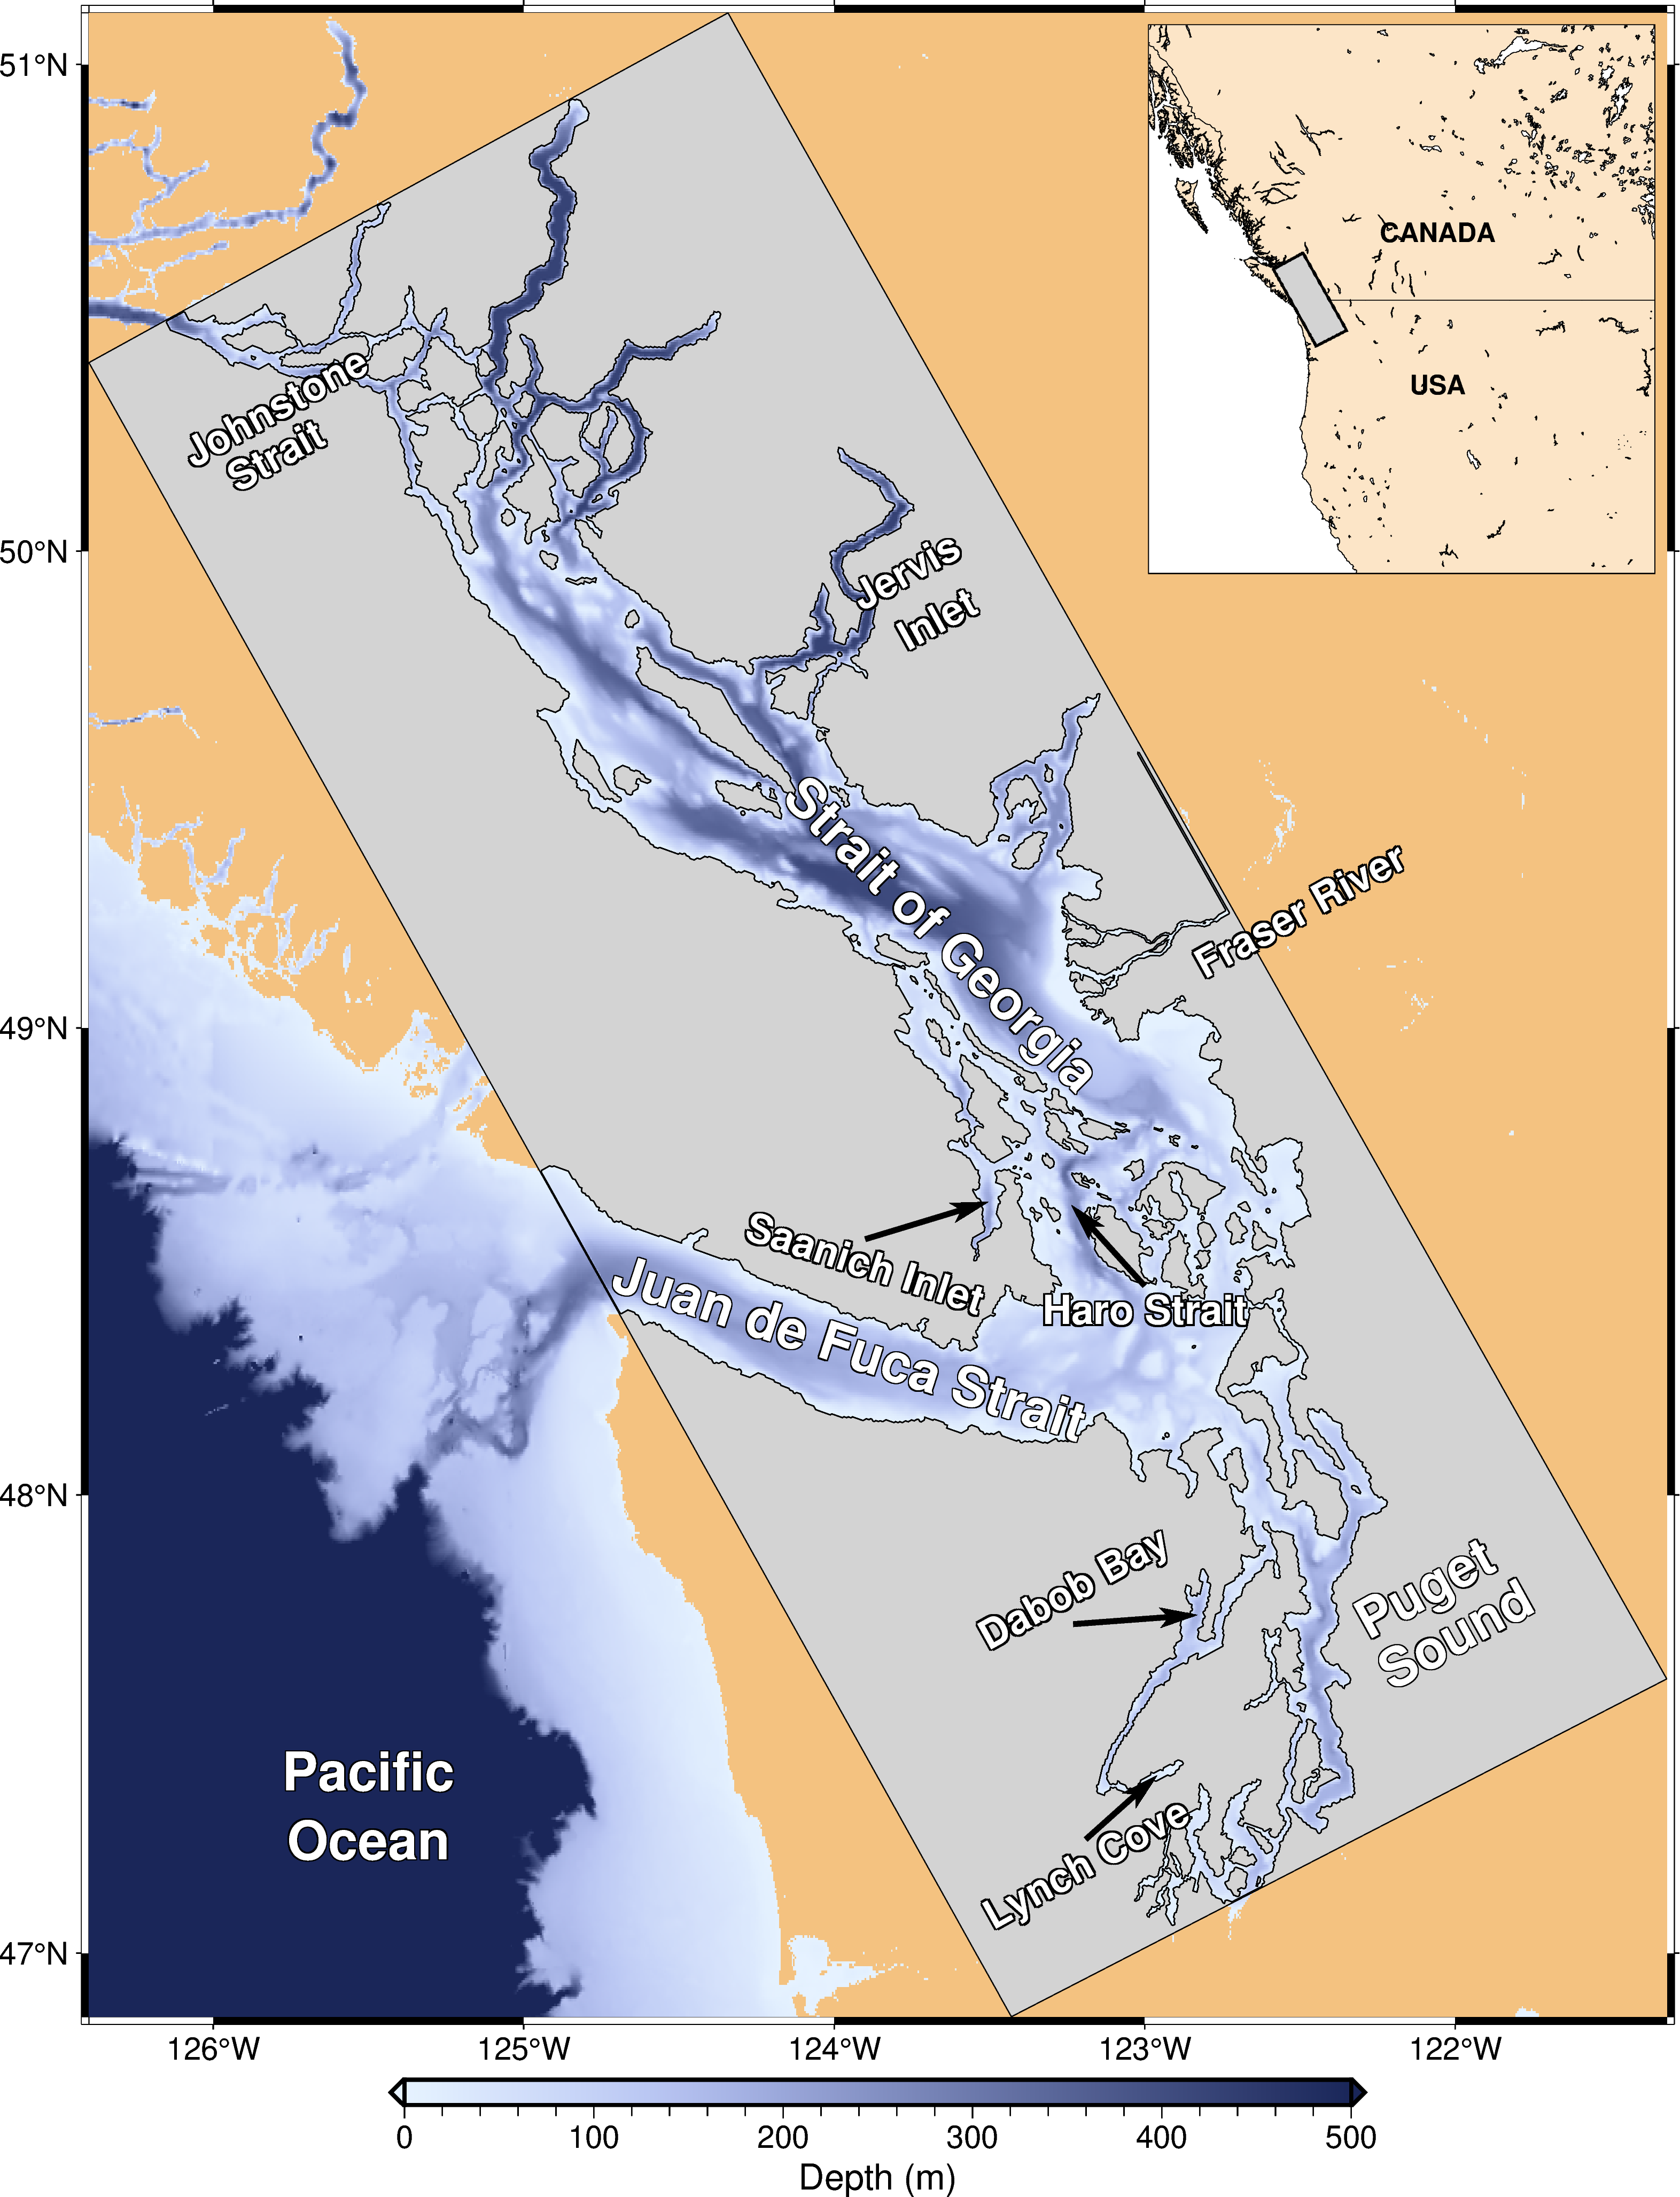

In [9]:
add_text_with_outline(fig, x=-123.65, y=49.2, text="Strait of Georgia", angle=-45)

add_text_with_outline(fig, x=-123.95, y=48.32, text="Juan de Fuca Strait", angle=-18)

add_text_with_outline(fig, x=-122.1, y=47.8, text="Puget", angle=29)
add_text_with_outline(fig, x=-122.0, y=47.7, text="Sound", angle=29)

add_text_with_outline(fig, x=-125.5, y=47.4, text="Pacific", angle=0)
add_text_with_outline(fig, x=-125.5, y=47.25, text="Ocean", angle=0)

add_text_with_outline(fig, x=-123, y=48.4, text="Haro Strait", angle=0,size = 18,stroke=0.03,arrowx = -123.236,arrowy = 48.623)

add_text_with_outline(fig, x=-123.9, y=48.5, text="Saanich Inlet", angle=-18,size = 18,stroke=0.03,arrowx = -123.503,arrowy = 48.63)

add_text_with_outline(fig, x=-123.23, y=47.8, text="Dabob Bay", angle=29,size = 18,stroke=0.03,arrowx = -122.83,arrowy = 47.74,arrowoff = -0.08)

add_text_with_outline(fig, x=-123.19, y=47.2, text="Lynch Cove", angle=29,size = 18,stroke=0.03,arrowx = -122.96,arrowy = 47.39)

add_text_with_outline(fig, x= -122.5, y=49.25, text="Fraser River", angle=29,size = 18,stroke=0.03)

add_text_with_outline(fig, x=-125.8, y=50.3, text="Johnstone", angle=29,size = 18,stroke=0.03)
add_text_with_outline(fig, x=-125.8, y=50.2, text="Strait", angle=29,size = 18,stroke=0.03)

add_text_with_outline(fig, x= -123.77, y=49.96, text="Jervis", angle=29,size = 18,stroke=0.03)
add_text_with_outline(fig, x= -123.67, y=49.86, text="Inlet", angle=29,size = 18,stroke=0.03)

fig.show()

In [10]:
fig.savefig("salishmapGMT.pdf")